# 3L - Caracterizacao das 4 fases: El Nino x La Nina (camada visual)

**Projeto NINO-BRASIL - Oceanografia Fisica UFPE - Thiago Vilar**

**Pergunta.** Como El Nino e La Nina percorrem os 4 periodos (genese, crescimento, pico, decaimento), quanto dura cada fase por classe, e quais variaveis melhor delimitam cada periodo?

**Insumos** (gerados por `scripts/phase3_en_ln.py` a partir da matriz-mestre semanal):
`phase3_events_en_ln.csv`, `phase3_fases_semanais_en_ln.csv`, `phase3_event_lifecycle_en_ln.csv`, `phase3_duracao_por_tipo_classe.csv`, `phase3_fase_stats_variaveis.csv`, `phase3_discriminantes_por_periodo.csv`, `phase3_pca_por_fase.csv`.

**Saidas.** Figuras espelhadas EN/LN: ciclo de vida composto, duracao por fase, heatmap discriminante e PCA por fase. Sem ML, escala semanal.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import fase3_utils as u
STATS, FIGS = u.STATS, u.FIGS
m = u.weekly_matrix()                       # matriz-mestre (31 vars quando completa)
lc = pd.read_csv(STATS/'phase3_fases_semanais_en_ln.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = pd.read_csv(STATS/'phase3_events_en_ln.csv', parse_dates=['onset','pico','fim'])
dur = pd.read_csv(STATS/'phase3_duracao_por_tipo_classe.csv')
disc = pd.read_csv(STATS/'phase3_discriminantes_por_periodo.csv')
pcs = pd.read_csv(STATS/'phase3_pca_por_fase.csv')
FASES = ['genese','crescimento','pico','decaimento']
FCOR = {'genese':'#93c5fd','crescimento':'#fca5a5','pico':'#111827','decaimento':'#d1d5db'}
print('master', m.shape, '|', m.index.min().date(),'->',m.index.max().date())
print('eventos: EN', int((ev.tipo=="el_nino").sum()), '| LN', int((ev.tipo=="la_nina").sum()))

master (2372, 31) | 1981-01-04 -> 2026-06-14
eventos: EN 12 | LN 11


[figura] data/processed/figures/fase3/phase3L_ciclo_vida_en_ln.png


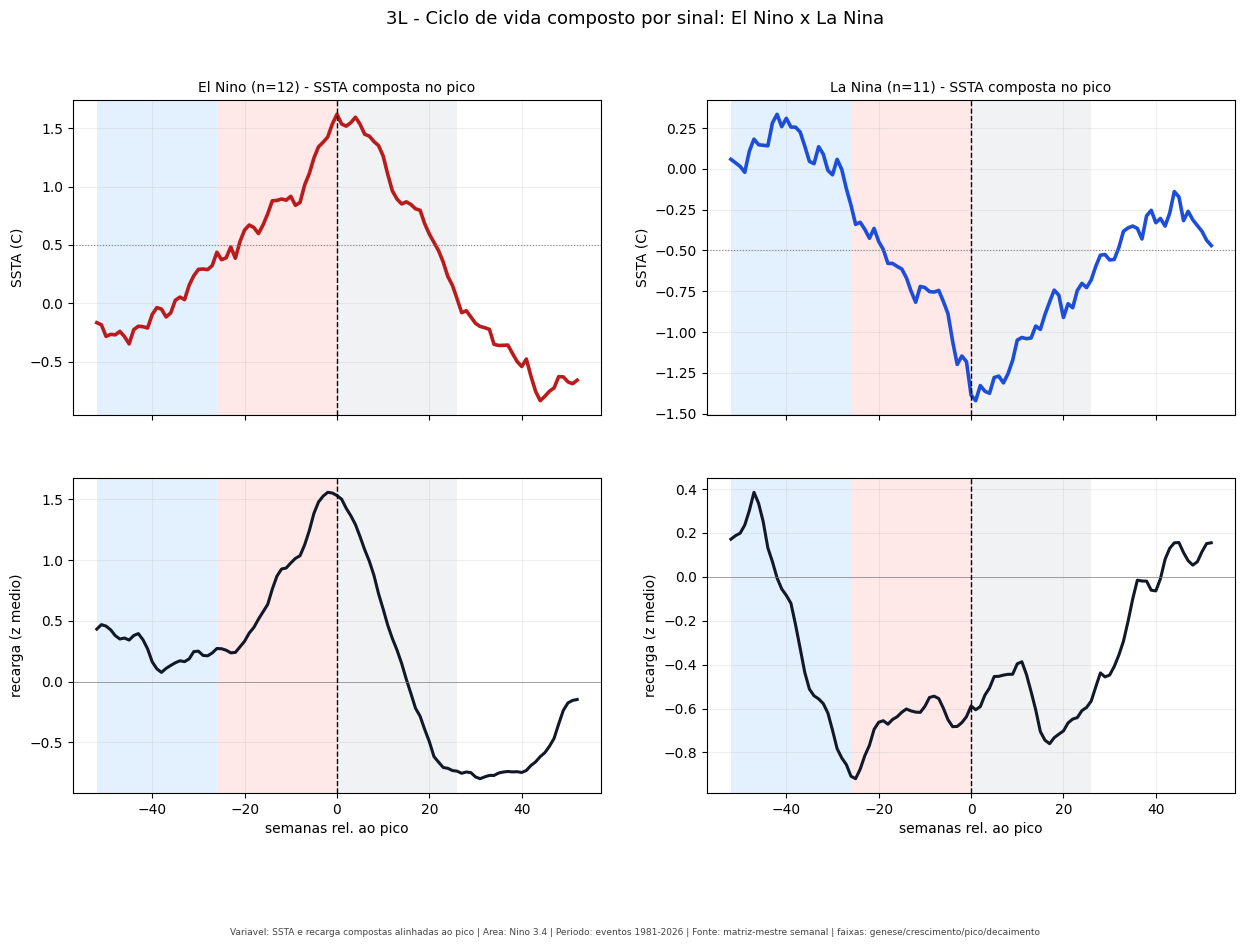

In [2]:
# Fig 1: ciclo de vida composto alinhado ao pico, El Nino x La Nina (SSTA + recarga z)
REL = list(range(-52, 53))
def peak_al(s, peak):
    i = s.index.get_indexer([pd.to_datetime(peak)], method='nearest')[0]
    seg = s.iloc[max(0,i-52):i+53]; rel = ((seg.index - s.index[i]).days/7).round().astype(int)
    return pd.Series(seg.values, index=rel).reindex(REL)
RECARGA = [c for c in ['d20_m','ssh_m','ohc_0_300','wwv','tilt_m'] if c in m.columns]
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for j, tipo in enumerate(['el_nino','la_nina']):
    sub = ev[ev.tipo==tipo]
    ssta = pd.DataFrame([peak_al(m['nino34_ssta'], e.pico) for _,e in sub.iterrows()]).mean()
    zc = [ (m[v]-m[v].mean())/m[v].std() for v in RECARGA ]
    rec = pd.concat([pd.DataFrame([peak_al(z, e.pico) for _,e in sub.iterrows()]).mean() for z in zc], axis=1).mean(axis=1)
    axes[0,j].plot(REL, ssta.values, color='#b91c1c' if tipo=='el_nino' else '#1d4ed8', lw=2.6)
    axes[0,j].axhline(0.5 if tipo=='el_nino' else -0.5, color='0.5', ls=':', lw=.8)
    axes[0,j].set_title(f'{"El Nino" if tipo=="el_nino" else "La Nina"} (n={len(sub)}) - SSTA composta no pico', fontsize=10)
    axes[0,j].set_ylabel('SSTA (C)')
    axes[1,j].plot(REL, rec.values, color='#111827', lw=2.2)
    axes[1,j].axhline(0, color='0.5', lw=.5); axes[1,j].set_ylabel('recarga (z medio)'); axes[1,j].set_xlabel('semanas rel. ao pico')
    for ax in (axes[0,j], axes[1,j]):
        ax.axvspan(-52,-26,color=FCOR['genese'],alpha=.25,lw=0); ax.axvspan(-26,0,color=FCOR['crescimento'],alpha=.25,lw=0)
        ax.axvspan(0,26,color=FCOR['decaimento'],alpha=.3,lw=0); ax.axvline(0,color='k',ls='--',lw=1); ax.grid(alpha=.2)
fig.suptitle('3L - Ciclo de vida composto por sinal: El Nino x La Nina', fontsize=13)
u.stamp_caption(fig, variavel='SSTA e recarga compostas alinhadas ao pico', area='Nino 3.4', periodo='eventos 1981-2026', fonte='matriz-mestre semanal', extra='faixas: genese/crescimento/pico/decaimento')
u.save_fig(fig, 'phase3L_ciclo_vida_en_ln.png'); plt.show()

[figura] data/processed/figures/fase3/phase3L_duracao_fases_en_ln.png


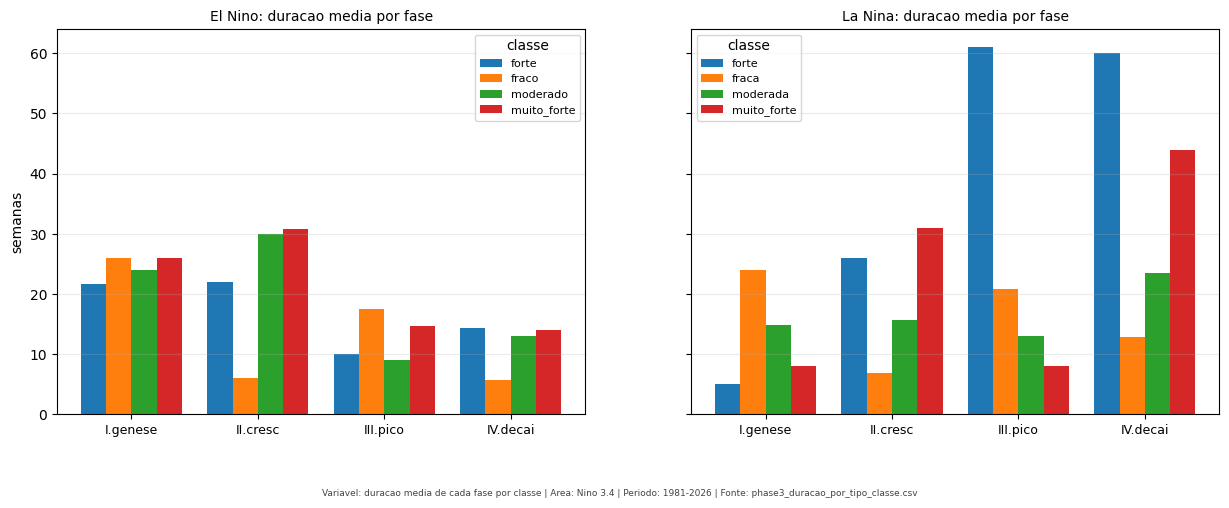

In [3]:
# Fig 2: duracao media de cada fase, por classe, El Nino x La Nina
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, tipo in zip(axes, ['el_nino','la_nina']):
    d = dur[dur.tipo==tipo]
    classes = list(dict.fromkeys(d.classe))
    x = np.arange(len(FASES)); w = 0.8/max(len(classes),1)
    for k, cl in enumerate(classes):
        vals = [float(d[(d.classe==cl)&(d.fase==f)]['duracao_media_semanas'].mean() or 0) for f in FASES]
        ax.bar(x + k*w, vals, width=w, label=cl)
    ax.set_xticks(x + w*(len(classes)-1)/2); ax.set_xticklabels(['I.genese','II.cresc','III.pico','IV.decai'], fontsize=9)
    ax.set_title(f'{"El Nino" if tipo=="el_nino" else "La Nina"}: duracao media por fase', fontsize=10)
    ax.legend(fontsize=8, title='classe'); ax.grid(axis='y', alpha=.25)
axes[0].set_ylabel('semanas')
u.stamp_caption(fig, variavel='duracao media de cada fase por classe', area='Nino 3.4', periodo='1981-2026', fonte='phase3_duracao_por_tipo_classe.csv')
u.save_fig(fig, 'phase3L_duracao_fases_en_ln.png'); plt.show()

[figura] data/processed/figures/fase3/phase3L_discriminantes_heatmap.png


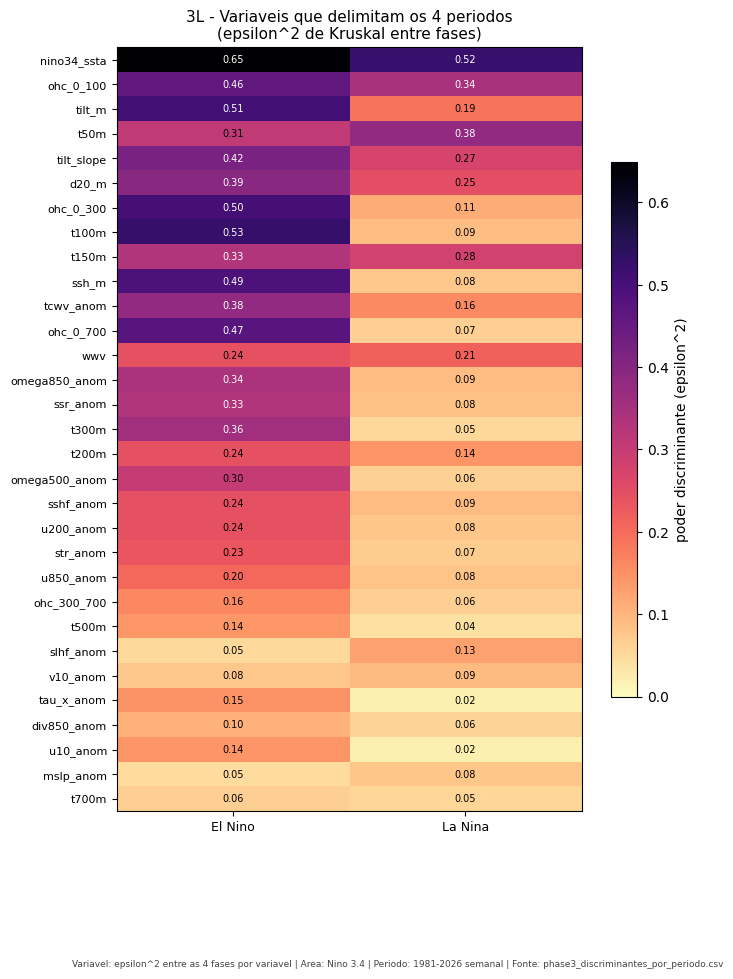

In [4]:
# Fig 3: heatmap do poder discriminante (quais variaveis delimitam as 4 fases), EN x LN
piv = disc.pivot(index='variavel', columns='tipo', values='epsilon2_entre_fases')
piv = piv.reindex(piv.mean(axis=1).sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(7.5, max(6, .32*len(piv))))
im = ax.imshow(piv.values, cmap='magma_r', aspect='auto', vmin=0, vmax=float(np.nanmax(piv.values)))
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(['El Nino' if c=='el_nino' else 'La Nina' for c in piv.columns], fontsize=9)
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=8)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i,j]
        if np.isfinite(v): ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=7,color='white' if v>0.5*np.nanmax(piv.values) else 'black')
ax.set_title('3L - Variaveis que delimitam os 4 periodos\n(epsilon^2 de Kruskal entre fases)', fontsize=11)
fig.colorbar(im, ax=ax, shrink=.7, label='poder discriminante (epsilon^2)')
u.stamp_caption(fig, variavel='epsilon^2 entre as 4 fases por variavel', area='Nino 3.4', periodo='1981-2026 semanal', fonte='phase3_discriminantes_por_periodo.csv')
u.save_fig(fig, 'phase3L_discriminantes_heatmap.png'); plt.show()

[figura] data/processed/figures/fase3/phase3L_pca_por_fase.png


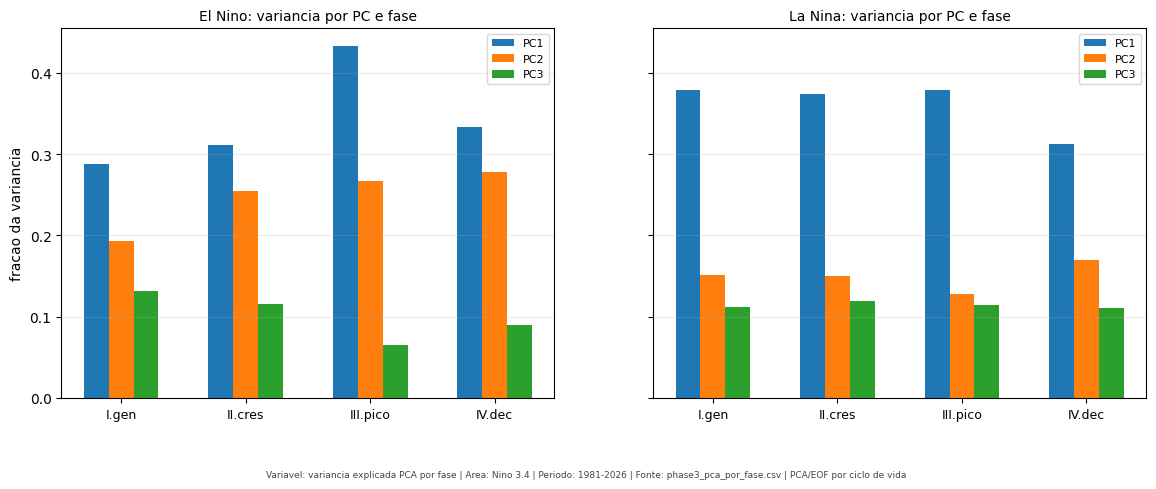

In [5]:
# Fig 4: variancia PCA por fase e por sinal (quantas dimensoes por periodo)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, tipo in zip(axes, ['el_nino','la_nina']):
    sub = pcs[pcs.tipo==tipo]
    x = np.arange(len(FASES)); w=0.2
    for k in range(1,4):
        pc = sub[sub.componente==f'PC{k}']
        vals = [float(pc[pc.fase==f]['var_explicada'].mean() or 0) for f in FASES]
        ax.bar(x + (k-2)*w, vals, width=w, label=f'PC{k}')
    ax.set_xticks(x); ax.set_xticklabels(['I.gen','II.cres','III.pico','IV.dec'], fontsize=9)
    ax.set_title(f'{"El Nino" if tipo=="el_nino" else "La Nina"}: variancia por PC e fase', fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=.25)
axes[0].set_ylabel('fracao da variancia')
u.stamp_caption(fig, variavel='variancia explicada PCA por fase', area='Nino 3.4', periodo='1981-2026', fonte='phase3_pca_por_fase.csv', extra='PCA/EOF por ciclo de vida')
u.save_fig(fig, 'phase3L_pca_por_fase.png'); plt.show()

**Leitura do 3L.** As figuras fecham a camada visual da Fase 3 para os dois sinais: o ciclo de vida composto mostra a recarga liderando o aquecimento no El Nino e a descarga espelhada na La Nina; a duracao por fase separa fracos de fortes/super; o heatmap identifica as variaveis que melhor delimitam cada periodo (SSTA, tilt e recarga subsuperficial no topo); e a PCA por fase quantifica quantas dimensoes fisicas cada periodo exige. Todos os numeros vem das tabelas `phase3_*_en_ln.csv`.